<a href="https://colab.research.google.com/github/codeishitech/Predicting-Primary-Visual-Cortex-V1-Neural-Responses/blob/main/notebooks/03_rf_cropped_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print(mean_centered_response.shape)
print(vgg_features.shape)
print(per_neuron_ev.mean())

In [ ]:
# Run ONE image through and check the raw spatial size before pooling
test_tensor = preprocess(img_stck[0].astype(np.uint8)).unsqueeze(0)

spatial_activations = {}
def hook_spatial(module, input, output):
    spatial_activations['raw'] = output

handle_test = vgg.features[16].register_forward_hook(hook_spatial)
with torch.no_grad():
    vgg(test_tensor)
handle_test.remove()

raw_shape = spatial_activations['raw'].shape
print("Raw feature map shape: [batch, channels, H, W] =", raw_shape)
# expecting something like [1, 256, 28, 28]

feat_H = raw_shape[2]
feat_W = raw_shape[3]
print(f"Spatial grid: {feat_H} x {feat_W}")

just converted "degrees on screen" into "which cell in the 28×28 grid." The radius conversion does the same thing for the RF's size (how big a patch the neuron covers), using the var(x), var(y) values from RF_SPATIAL as a measure of spread.

In [ ]:
# Image is 320x320 pixels covering roughly 120 x 95 degrees visual angle
# RF_SPATIAL gives positions in degrees, relative to image center (0,0)
img_deg_W = 120.0
img_deg_H = 95.0
img_px = 320

# Degrees per pixel in original image
deg_per_px_W = img_deg_W / img_px
deg_per_px_H = img_deg_H / img_px

# After VGG-16 downsampling, each feature map cell covers:
deg_per_cell_W = img_deg_W / feat_W
deg_per_cell_H = img_deg_H / feat_H

print(f"Each feature map cell covers: {deg_per_cell_W:.2f} deg (W) x {deg_per_cell_H:.2f} deg (H)")

# Get RF positions for centered neurons
rf_spatial_centered = mat['RF_SPATIAL'][cen_neurons, :]
rf_x = rf_spatial_centered[:, 0]   # horizontal position in degrees
rf_y = rf_spatial_centered[:, 1]   # vertical position in degrees
rf_var_x = rf_spatial_centered[:, 2]  # spread/size in x
rf_var_y = rf_spatial_centered[:, 3]  # spread/size in y

# Convert RF center positions from degrees to feature map cell indices
# Feature map center = (feat_H/2, feat_W/2)
rf_cell_x = (rf_x / deg_per_cell_W + feat_W / 2).astype(int)
rf_cell_y = (rf_y / deg_per_cell_H + feat_H / 2).astype(int)

# Clip to valid range (some peripheral RFs might map outside the feature map)
rf_cell_x = np.clip(rf_cell_x, 0, feat_W - 1)
rf_cell_y = np.clip(rf_cell_y, 0, feat_H - 1)

# RF radius in feature map cells (using sqrt of variance as std dev, then convert)
rf_radius_x = np.maximum(1, (np.sqrt(rf_var_x) / deg_per_cell_W).astype(int))
rf_radius_y = np.maximum(1, (np.sqrt(rf_var_y) / deg_per_cell_H).astype(int))

print("\nNeuron RF positions in feature map space:")
for i in range(len(rf_cell_x)):
    print(f"  Neuron {i}: center=({rf_cell_x[i]}, {rf_cell_y[i]}) radius=({rf_radius_x[i]}, {rf_radius_y[i]})")

In [ ]:
# Store raw spatial feature maps for all images (before any pooling)
# Shape will be [540, 256, 28, 28]

all_spatial_features = []
activations_spatial = {}

def hook_spatial_full(module, input, output):
    activations_spatial['raw'] = output

handle_full = vgg.features[16].register_forward_hook(hook_spatial_full)

batch_size = 32
with torch.no_grad():
    for i in range(0, len(img_stck), batch_size):
        batch_imgs = img_stck[i:i+batch_size]
        batch_tensors = torch.stack([
            preprocess(img.astype(np.uint8)) for img in batch_imgs
        ])
        vgg(batch_tensors)
        # Store raw spatial maps, not pooled — shape: [batch, 256, 28, 28]
        all_spatial_features.append(
            activations_spatial['raw'].numpy()
        )
        print(f"Processed {i+len(batch_imgs)}/540")

handle_full.remove()

# Stack into one big array: [540, 256, 28, 28]
spatial_feature_maps = np.concatenate(all_spatial_features, axis=0)
print("Full spatial feature map shape:", spatial_feature_maps.shape)

In [ ]:
# For each neuron, extract features from only its RF region
# Result: one (540, 256) feature matrix per neuron
# Stored as a list of 26 matrices

rf_cropped_features = []  # will be list of 26 arrays, each (540, 256)

for n in range(26):
    cx = rf_cell_x[n]   # RF center x in feature map
    cy = rf_cell_y[n]   # RF center y in feature map
    rx = rf_radius_x[n] # RF radius x
    ry = rf_radius_y[n] # RF radius y

    # Define crop window, clipped to valid feature map bounds
    x_min = max(0, cx - rx)
    x_max = min(feat_W, cx + rx + 1)
    y_min = max(0, cy - ry)
    y_max = min(feat_H, cy + ry + 1)

    # Crop the spatial feature map to just this RF region
    # spatial_feature_maps shape: [540, 256, H, W]
    # We want: [540, 256, y_window, x_window] → average y,x → [540, 256]
    cropped = spatial_feature_maps[:, :, y_min:y_max, x_min:x_max]
    pooled = cropped.mean(axis=(2, 3))  # average only within RF region

    rf_cropped_features.append(pooled)
    print(f"Neuron {n}: RF crop [{y_min}:{y_max}, {x_min}:{x_max}] → features shape {pooled.shape}")

print("\nDone. Number of per-neuron feature matrices:", len(rf_cropped_features))

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import explained_variance_score
import numpy as np

# Use the same train/test image split as before for fair comparison
# random_state=42 guarantees identical split
alphas = [1.0, 10.0, 100.0, 1000.0, 5000.0, 10000.0]

ev_rf_cropped = []  # one EV score per neuron

for n in range(26):
    X_n = rf_cropped_features[n]        # (540, 256) — this neuron's RF-cropped features
    y_n = mean_centered_response[n, :]  # (540,) — this neuron's firing rates

    # Same split, same random state as baseline
    X_train, X_test, y_train, y_test = train_test_split(
        X_n, y_n, test_size=0.2, random_state=42
    )

    model_n = RidgeCV(alphas=alphas)
    model_n.fit(X_train, y_train)
    y_pred_n = model_n.predict(X_test)

    ev = explained_variance_score(y_test, y_pred_n)
    ev_rf_cropped.append(ev)

ev_rf_cropped = np.array(ev_rf_cropped)
print("Done training 26 models.")
print(f"Mean EV (RF-cropped): {ev_rf_cropped.mean():.4f}")
print(f"Mean EV (baseline global pool): {per_neuron_ev.mean():.4f}")

In [ ]:
print("\nPer-neuron comparison:")
print(f"{'Neuron':<10} {'Baseline EV':<16} {'RF-Cropped EV':<16} {'Change'}")
print("-" * 55)
for i in range(26):
    change = ev_rf_cropped[i] - per_neuron_ev[i]
    direction = "↑" if change > 0 else "↓"
    print(f"{i:<10} {per_neuron_ev[i]:<16.3f} {ev_rf_cropped[i]:<16.3f} {direction} {abs(change):.3f}")

improved = (ev_rf_cropped > per_neuron_ev).sum()
print(f"\nNeurons that improved: {improved}/26")
print(f"Neurons that got worse: {26 - improved}/26")

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: side by side bar chart
x = np.arange(26)
width = 0.35
axes[0].bar(x - width/2, per_neuron_ev, width,
            label='Global pooling', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, ev_rf_cropped, width,
            label='RF-cropped pooling', color='coral', alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Neuron')
axes[0].set_ylabel('Explained Variance')
axes[0].set_title('Per-neuron EV: Global vs RF-cropped pooling')
axes[0].legend()
axes[0].set_xticks(x)

# Plot 2: scatter — baseline vs RF-cropped
axes[1].scatter(per_neuron_ev, ev_rf_cropped,
                color='coral', s=60, zorder=3)
lim = [-0.15, 0.45]
axes[1].plot(lim, lim, 'k--', linewidth=1, label='No change line')
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel('Baseline EV (global pooling)')
axes[1].set_ylabel('RF-cropped EV')
axes[1].set_title('Each point = one neuron\n(above diagonal = improved)')
axes[1].legend()

# Label a few interesting neurons
for i in [0, 5, 9, 20, 8, 24]:
    axes[1].annotate(f'N{i}',
        (per_neuron_ev[i], ev_rf_cropped[i]),
        textcoords="offset points", xytext=(6, 4), fontsize=8)

# Plot 3: improvement magnitude
improvement = ev_rf_cropped - per_neuron_ev
colors = ['coral' if v > 0 else 'steelblue' for v in improvement]
axes[2].bar(x, improvement, color=colors, alpha=0.8)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_xlabel('Neuron')
axes[2].set_ylabel('EV change (RF-cropped minus baseline)')
axes[2].set_title('Improvement per neuron\n(coral = improved, blue = declined)')
axes[2].set_xticks(x)

plt.tight_layout()
plt.savefig('rf_cropped_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

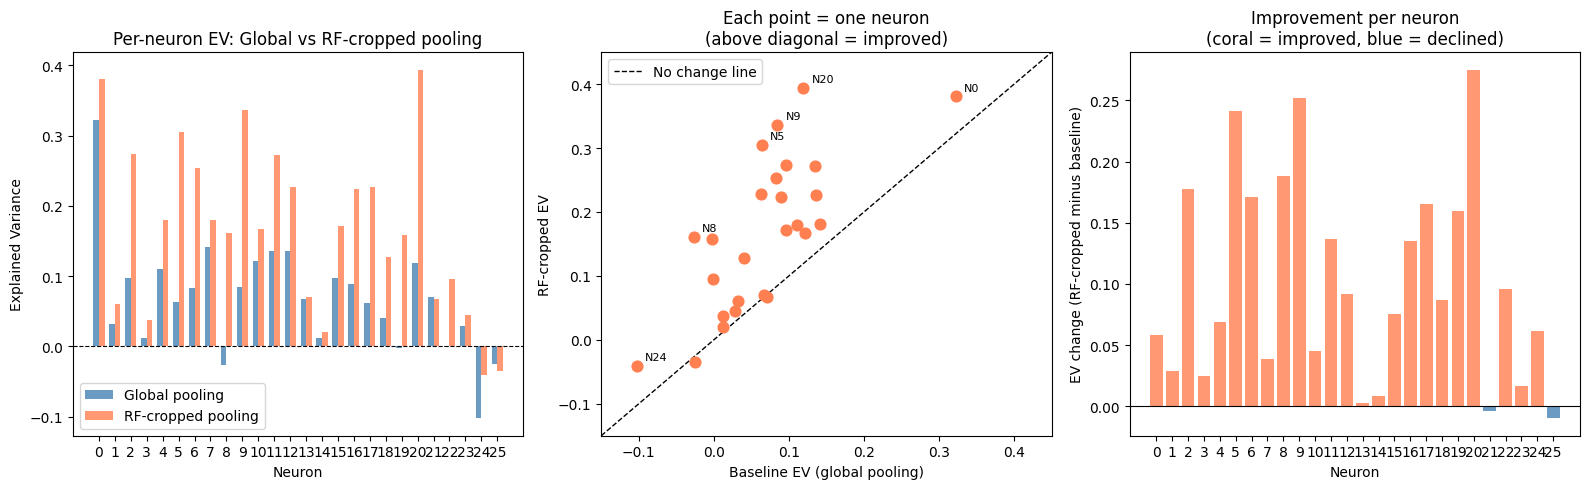

In [ ]:
vgg_features = np.load('vgg_features.npy')
mean_response_centered = np.load('mean_response_centered.npy')
centered_neurons = np.load('centered_neurons.npy')